# **Practical Lesson 1**
## ECG classification: synus rythm vs atrial fibrillation

**Professor:** Valentina Corino

**Teaching assistant:** Meri Ferretti &lt;meri.ferretti@polimi.it&gt;

---


In [2]:
# from google.colab import drive
from pathlib import Path

# ROOT_PATH = '/content/drive'
# drive.mount(ROOT_PATH)

In [1]:
# support functions
from scipy.io import loadmat
import numpy as np, os, sys, joblib
from tqdm import tqdm
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter
from scipy import stats
from sklearn.model_selection import train_test_split
import random
import seaborn as sns
from sklearn import svm
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# reproducibility
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# **1.** Data analysis

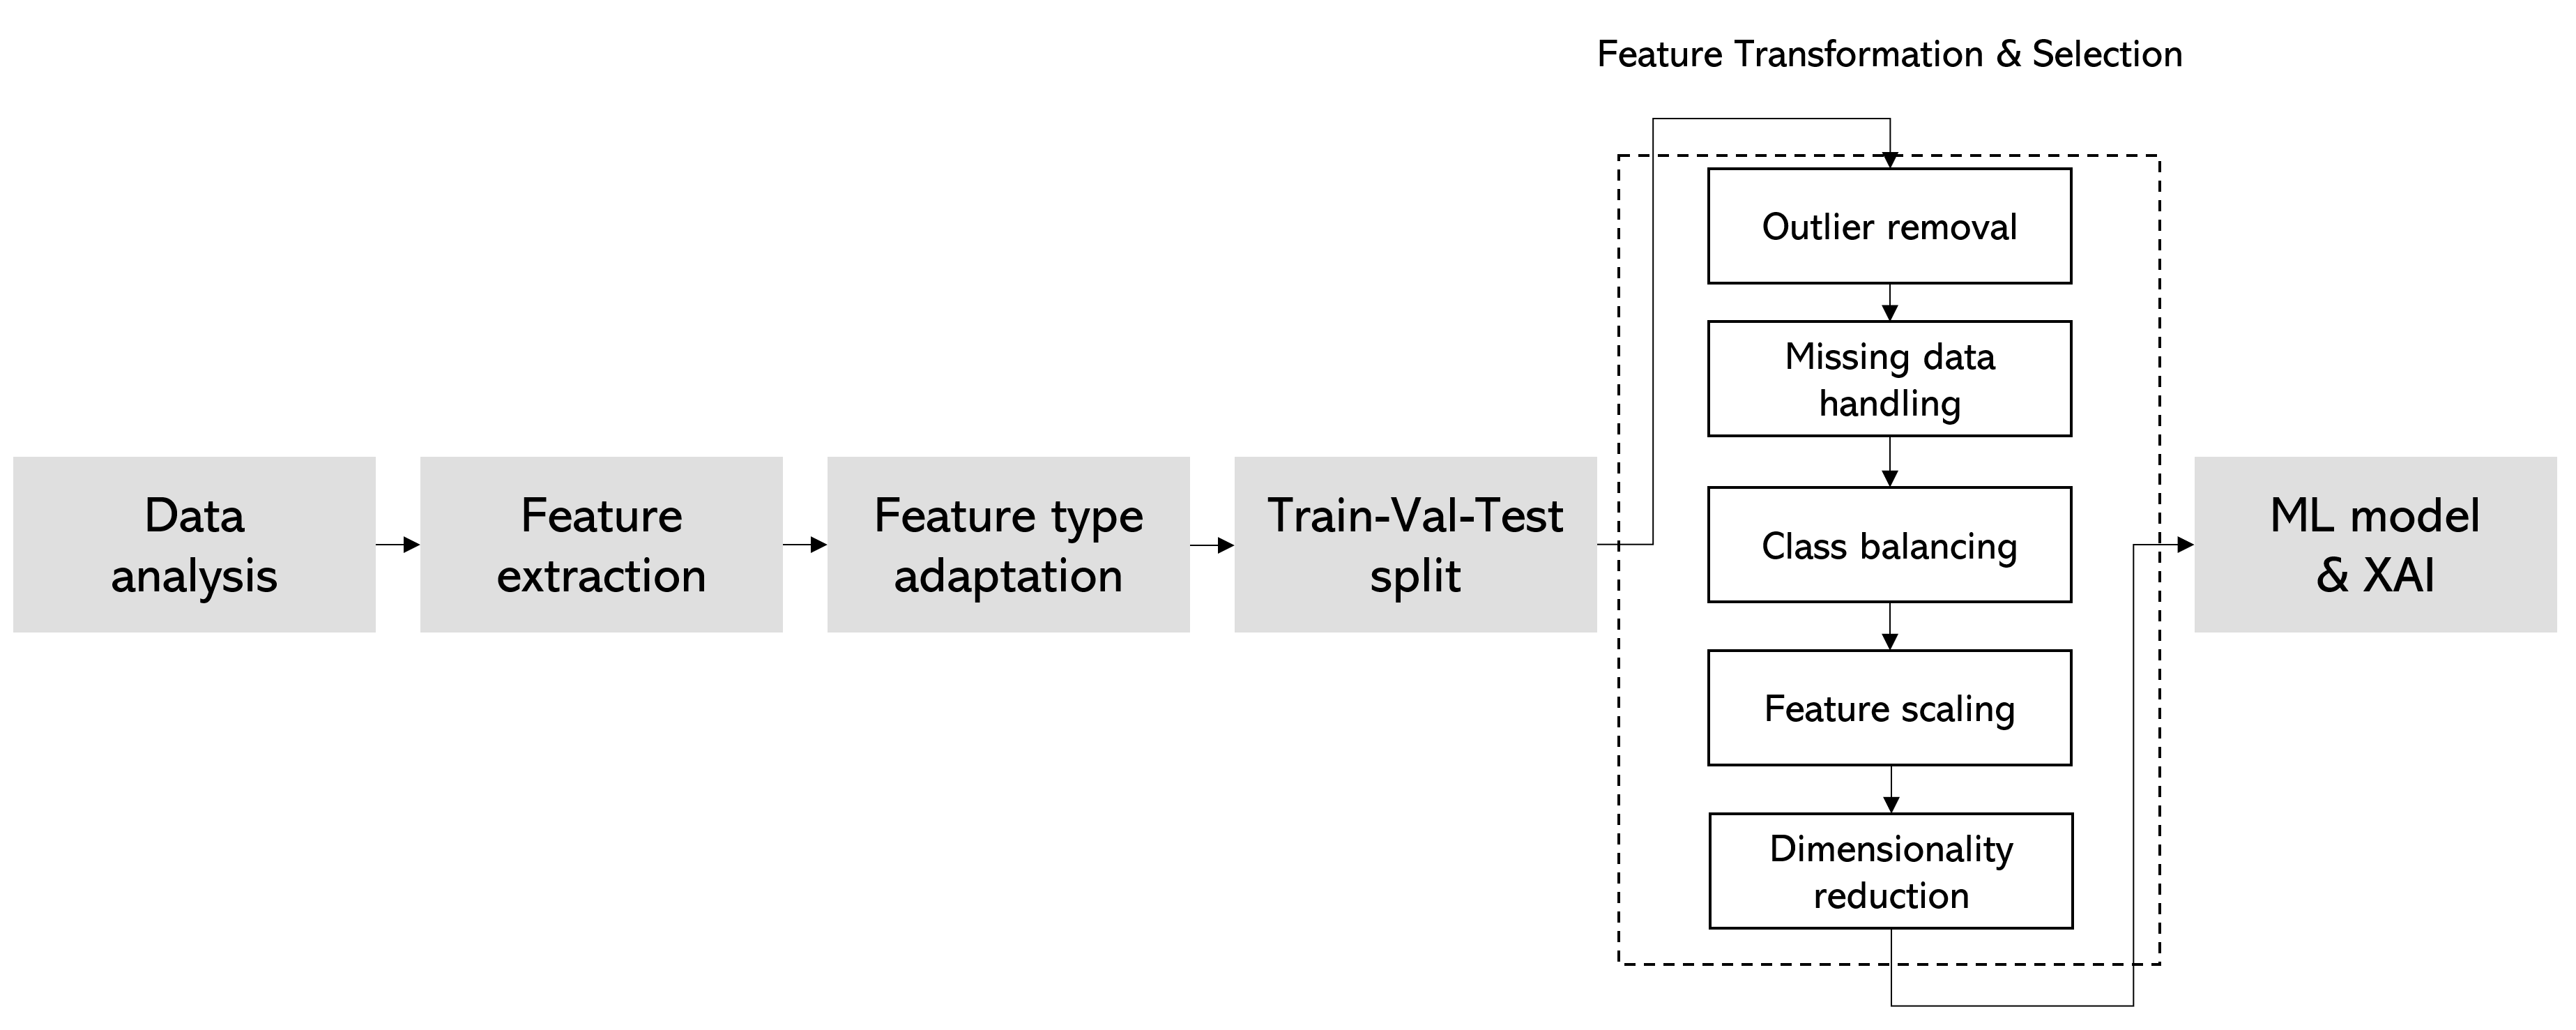

## **1.1.** Loading data files

In [3]:
# Path of folder containing data
input_directory ='data'

# Import header files (.hea files) contained in the folder
print('Loading data...')
header_files = []
for f in os.listdir(input_directory):
    g = os.path.join(input_directory, f)
    if not f.lower().startswith('.') and f.lower().endswith('hea') and os.path.isfile(g):
        header_files.append(g)
num_files = len(header_files)

# Create empty list for recordings and header files
recordings = list()
headers = list()

# Define a function to load signal and header
def load_data(header_file):
  with open(header_file, 'r') as f:
      header = f.readlines()
  mat_file = header_file.replace('.hea', '.mat')
  x = loadmat(mat_file)
  recording = np.asarray(x['val'], dtype=np.float64)
  return recording, header

# Load .mat and .hea files for each subject using the function "load_data"
for i in tqdm(range(num_files), desc="Loading files", unit="file"):
    recording, header = load_data(header_files[i])
    recordings.append(recording)
    headers.append(header)

Loading data...


Loading files: 100%|██████████| 760/760 [00:00<00:00, 1958.65file/s]


In [4]:
# print the last header loaded
header

['A1501 12 500 5500 12-May-2020 12:33:59\n',
 'A1501.mat 16+24 1000/mV 16 0 248 -2054 0 I\n',
 'A1501.mat 16+24 1000/mV 16 0 722 476 0 II\n',
 'A1501.mat 16+24 1000/mV 16 0 474 2530 0 III\n',
 'A1501.mat 16+24 1000/mV 16 0 -485 -2154 0 aVR\n',
 'A1501.mat 16+24 1000/mV 16 0 -112 864 0 aVL\n',
 'A1501.mat 16+24 1000/mV 16 0 598 1832 0 aVF\n',
 'A1501.mat 16+24 1000/mV 16 0 -374 2684 0 V1\n',
 'A1501.mat 16+24 1000/mV 16 0 -482 -884 0 V2\n',
 'A1501.mat 16+24 1000/mV 16 0 262 -1917 0 V3\n',
 'A1501.mat 16+24 1000/mV 16 0 943 -841 0 V4\n',
 'A1501.mat 16+24 1000/mV 16 0 996 -288 0 V5\n',
 'A1501.mat 16+24 1000/mV 16 0 998 2639 0 V6\n',
 '#Age: 23\n',
 '#Sex: Female\n',
 '#Dx: 426783006\n',
 '#Rx: Unknown\n',
 '#Hx: Unknown\n',
 '#Sx: Unknown\n']

In [5]:
# print the last set of signals loaded
recording

array([[ 248.,  232.,  223., ...,  131.,  131.,  136.],
       [ 722.,  782.,  776., ...,   99.,  103.,  110.],
       [ 474.,  550.,  553., ...,  -32.,  -28.,  -26.],
       ...,
       [ 943., 1022., 1054., ...,   77.,   82.,   94.],
       [ 996., 1088., 1111., ...,  129.,  136.,  148.],
       [ 998., 1078., 1091., ...,   87.,   96.,  103.]], shape=(12, 5500))

In [6]:
print(np.shape(recording))

(12, 5500)


## **1.2.** Plot label distribution

In [7]:
header

['A1501 12 500 5500 12-May-2020 12:33:59\n',
 'A1501.mat 16+24 1000/mV 16 0 248 -2054 0 I\n',
 'A1501.mat 16+24 1000/mV 16 0 722 476 0 II\n',
 'A1501.mat 16+24 1000/mV 16 0 474 2530 0 III\n',
 'A1501.mat 16+24 1000/mV 16 0 -485 -2154 0 aVR\n',
 'A1501.mat 16+24 1000/mV 16 0 -112 864 0 aVL\n',
 'A1501.mat 16+24 1000/mV 16 0 598 1832 0 aVF\n',
 'A1501.mat 16+24 1000/mV 16 0 -374 2684 0 V1\n',
 'A1501.mat 16+24 1000/mV 16 0 -482 -884 0 V2\n',
 'A1501.mat 16+24 1000/mV 16 0 262 -1917 0 V3\n',
 'A1501.mat 16+24 1000/mV 16 0 943 -841 0 V4\n',
 'A1501.mat 16+24 1000/mV 16 0 996 -288 0 V5\n',
 'A1501.mat 16+24 1000/mV 16 0 998 2639 0 V6\n',
 '#Age: 23\n',
 '#Sex: Female\n',
 '#Dx: 426783006\n',
 '#Rx: Unknown\n',
 '#Hx: Unknown\n',
 '#Sx: Unknown\n']

In [8]:
# Define a function to read the label from the header
def get_labels(headers):
  classes = list() # list that will contain all the labels from all the headers
  for header in headers:
    tmp = header[15] # 15th row in the header file --> '#Dx: 426783006\n'
    tmp = tmp.split(': ') # --> ['#Dx', '426783006\n']
    tmp = tmp[1] # --> '426783006\n'
    tmp = tmp.split(',') # split in case there are multiple diagnoses like ['426783006\n', '59118001\n']
    tmp = tmp[0] # take the first diagnosis only
    classes.append(tmp.rstrip("\n"))
  return classes


# get all labels from the loaded header files
labels = get_labels(headers)

In [9]:
labels

['426783006',
 '164889003',
 '164889003',
 '426783006',
 '164889003',
 '426783006',
 '426783006',
 '426783006',
 '164889003',
 '164889003',
 '164889003',
 '164889003',
 '426783006',
 '426783006',
 '164889003',
 '426783006',
 '164889003',
 '164889003',
 '164889003',
 '164889003',
 '426783006',
 '164889003',
 '164889003',
 '164889003',
 '426783006',
 '426783006',
 '164889003',
 '164889003',
 '164889003',
 '164889003',
 '426783006',
 '164889003',
 '164889003',
 '164889003',
 '164889003',
 '164889003',
 '164889003',
 '426783006',
 '164889003',
 '164889003',
 '164889003',
 '164889003',
 '426783006',
 '164889003',
 '164889003',
 '426783006',
 '426783006',
 '164889003',
 '164889003',
 '426783006',
 '164889003',
 '164889003',
 '164889003',
 '164889003',
 '426783006',
 '164889003',
 '164889003',
 '426783006',
 '426783006',
 '164889003',
 '164889003',
 '164889003',
 '164889003',
 '164889003',
 '164889003',
 '164889003',
 '426783006',
 '164889003',
 '164889003',
 '426783006',
 '426783006',
 '4267

In [10]:
print(np.shape(labels))

(760,)


In [11]:
# Adapt labels into AF or NSR
AF_code = '164889003'
NSR_code = '426783006'

labels_adapt = list()
for label_temp in labels:
  if AF_code in label_temp:
      labels_adapt.append('AF')
  elif  NSR_code in label_temp:
      labels_adapt.append('NSR')
  else:
    labels_adapt.append('Others')


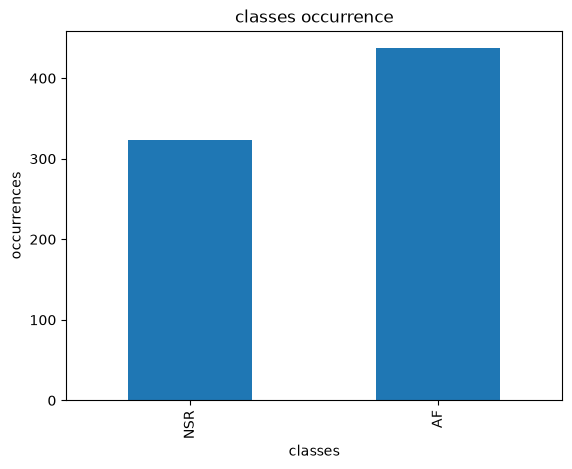

In [12]:
# Create label histogram using Counter and pandas Dataframe
label_counts = Counter(labels_adapt)
df = pd.DataFrame.from_dict(label_counts, orient='index')
df.plot(kind='bar', legend=False, title='classes occurrence', xlabel='classes', ylabel='occurrences')
plt.show()

In [13]:
df

,0
NSR,323
AF,437


## **1.3.** Plot signal length distribution


In [14]:
recording

array([[ 248.,  232.,  223., ...,  131.,  131.,  136.],
       [ 722.,  782.,  776., ...,   99.,  103.,  110.],
       [ 474.,  550.,  553., ...,  -32.,  -28.,  -26.],
       ...,
       [ 943., 1022., 1054., ...,   77.,   82.,   94.],
       [ 996., 1088., 1111., ...,  129.,  136.,  148.],
       [ 998., 1078., 1091., ...,   87.,   96.,  103.]], shape=(12, 5500))

In [15]:
print(np.shape(recording))

(12, 5500)


Text(0.5, 1.0, 'Signal length distribution')

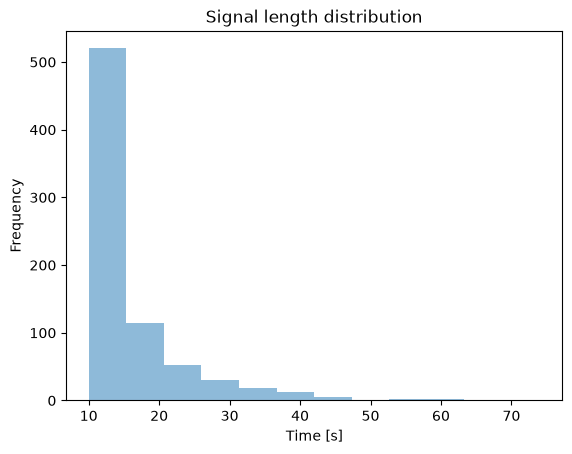

In [16]:
# Sampling frequency
fs = 500

# We know that: #samples = fs * duration
# So: duration = #samples / fs

# Create empty list to contain the different recording lenghts
recordings_duration = list()

# Iterate through the different signals stored in "recordings": store signal
# length and divide by sampling frequency to obtain it in seconds.
for rec in recordings:
  first_rec = rec[0,:]
  first_rec_duration = len(first_rec)/fs
  recordings_duration.append(first_rec_duration)

# Transform to pandas series and plot histogram.
recordings_duration_s = pd.Series(recordings_duration)
ax = recordings_duration_s.plot.hist(bins=12, alpha=0.5)
ax.set_xlabel("Time [s]")
ax.set_title("Signal length distribution")

## **1.4.** Plot a signal from each category


In [17]:
# Tranform labels_adapt to pandas series to be able to obtain a boolean vector
# containing the positions of AF and NSR labels
labels_adapt = pd.Series(labels_adapt)
idx_AF = labels_adapt == 'AF'
idx_NSR = labels_adapt == 'NSR'

pos_AF = np.where(idx_AF)[0]
pos_NSR = np.where(idx_NSR)[0]

# lead to plot
lead = 0

In [18]:
pos_NSR

array([  0,   3,   5,   6,   7,  12,  13,  15,  20,  24,  25,  30,  37,
        42,  45,  46,  49,  54,  57,  58,  66,  69,  70,  71,  72,  75,
        80,  81,  82,  83,  87,  88,  89,  91,  95, 102, 103, 104, 110,
       112, 113, 114, 115, 116, 118, 119, 120, 121, 122, 124, 125, 128,
       129, 132, 134, 136, 137, 140, 143, 146, 147, 155, 157, 161, 165,
       167, 169, 174, 177, 181, 182, 187, 188, 191, 192, 198, 199, 201,
       202, 204, 207, 209, 212, 215, 216, 217, 218, 219, 222, 223, 225,
       226, 228, 230, 231, 234, 235, 236, 238, 240, 241, 243, 253, 255,
       256, 258, 260, 261, 264, 265, 266, 267, 269, 272, 274, 275, 278,
       282, 284, 286, 288, 292, 294, 295, 297, 301, 302, 303, 306, 312,
       313, 315, 317, 318, 320, 324, 329, 333, 334, 336, 337, 341, 342,
       343, 346, 348, 350, 351, 352, 353, 358, 363, 364, 366, 367, 368,
       371, 372, 373, 375, 381, 383, 386, 390, 393, 396, 397, 403, 404,
       407, 411, 412, 414, 415, 418, 422, 424, 426, 427, 428, 43

In [19]:
pos_AF

array([  1,   2,   4,   8,   9,  10,  11,  14,  16,  17,  18,  19,  21,
        22,  23,  26,  27,  28,  29,  31,  32,  33,  34,  35,  36,  38,
        39,  40,  41,  43,  44,  47,  48,  50,  51,  52,  53,  55,  56,
        59,  60,  61,  62,  63,  64,  65,  67,  68,  73,  74,  76,  77,
        78,  79,  84,  85,  86,  90,  92,  93,  94,  96,  97,  98,  99,
       100, 101, 105, 106, 107, 108, 109, 111, 117, 123, 126, 127, 130,
       131, 133, 135, 138, 139, 141, 142, 144, 145, 148, 149, 150, 151,
       152, 153, 154, 156, 158, 159, 160, 162, 163, 164, 166, 168, 170,
       171, 172, 173, 175, 176, 178, 179, 180, 183, 184, 185, 186, 189,
       190, 193, 194, 195, 196, 197, 200, 203, 205, 206, 208, 210, 211,
       213, 214, 220, 221, 224, 227, 229, 232, 233, 237, 239, 242, 244,
       245, 246, 247, 248, 249, 250, 251, 252, 254, 257, 259, 262, 263,
       268, 270, 271, 273, 276, 277, 279, 280, 281, 283, 285, 287, 289,
       290, 291, 293, 296, 298, 299, 300, 304, 305, 307, 308, 30

In [20]:
len(pos_AF)

437

In [21]:
len(pos_NSR)

323

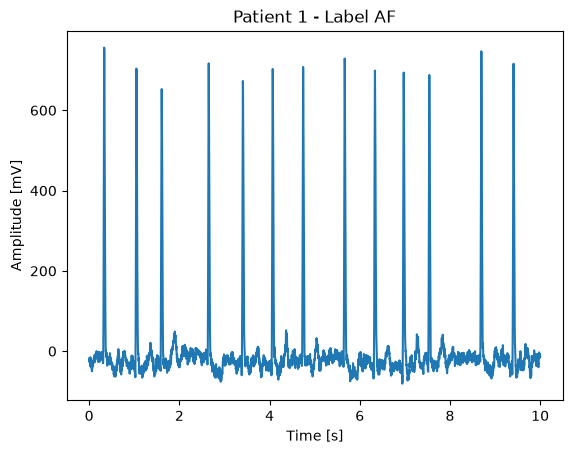

In [25]:
# AF patient
patient = pos_AF[0] # first index
signal = recordings[patient] # recording corresponding to that index
t = np.arange(0, signal.shape[1]/fs, 1/fs) # create time array
fig, axs = plt.subplots() # create the figure
axs.set_title("Patient " + str(patient) + " - Label " + labels_adapt[patient])
axs.plot(t, signal[lead,:], color='C0')
axs.set_xlabel("Time [s]")
axs.set_ylabel("Amplitude [mV]")
plt.show()

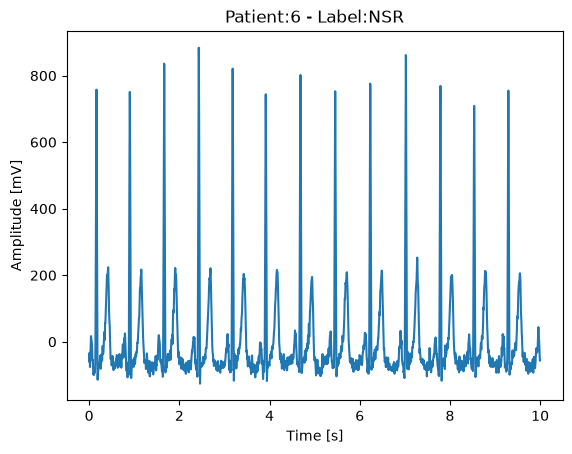

In [23]:
# NSR patient
patient = pos_NSR[3]
signal = recordings[patient]
t = np.arange(0, signal.shape[1]/fs, 1/fs)
fig, axs = plt.subplots()
axs.set_title("Patient:" + str(patient) + " - Label:" + labels_adapt[patient])
axs.plot(t, signal[lead,:], color='C0')
axs.set_xlabel("Time [s]")
axs.set_ylabel("Amplitude [mV]")
plt.show()


Conclusions extracted from the analysis:

- **Is the dataset balanced or unbalanced?**

  Dataset is unbalanced (323 NSR vs 437 AF)


- **What type of features can I extract?**

  The database contains signals with different lenghts. Most signals are around 10 seconds. Their duration can give us information about the different features that can be extracted from the signals. In this case signals are not long enough to extract heart rate variability (HRV) features. We can extract temporal measures, vectorial measures, slopes...

- **How is the signal quality? Are there any patterns that differentiate the 2 classes?**

  (a) Good signal quality

  (b) Evident patterns: irregular waves in the AF, regular waves in the NSR


# **2.** Feature extraction
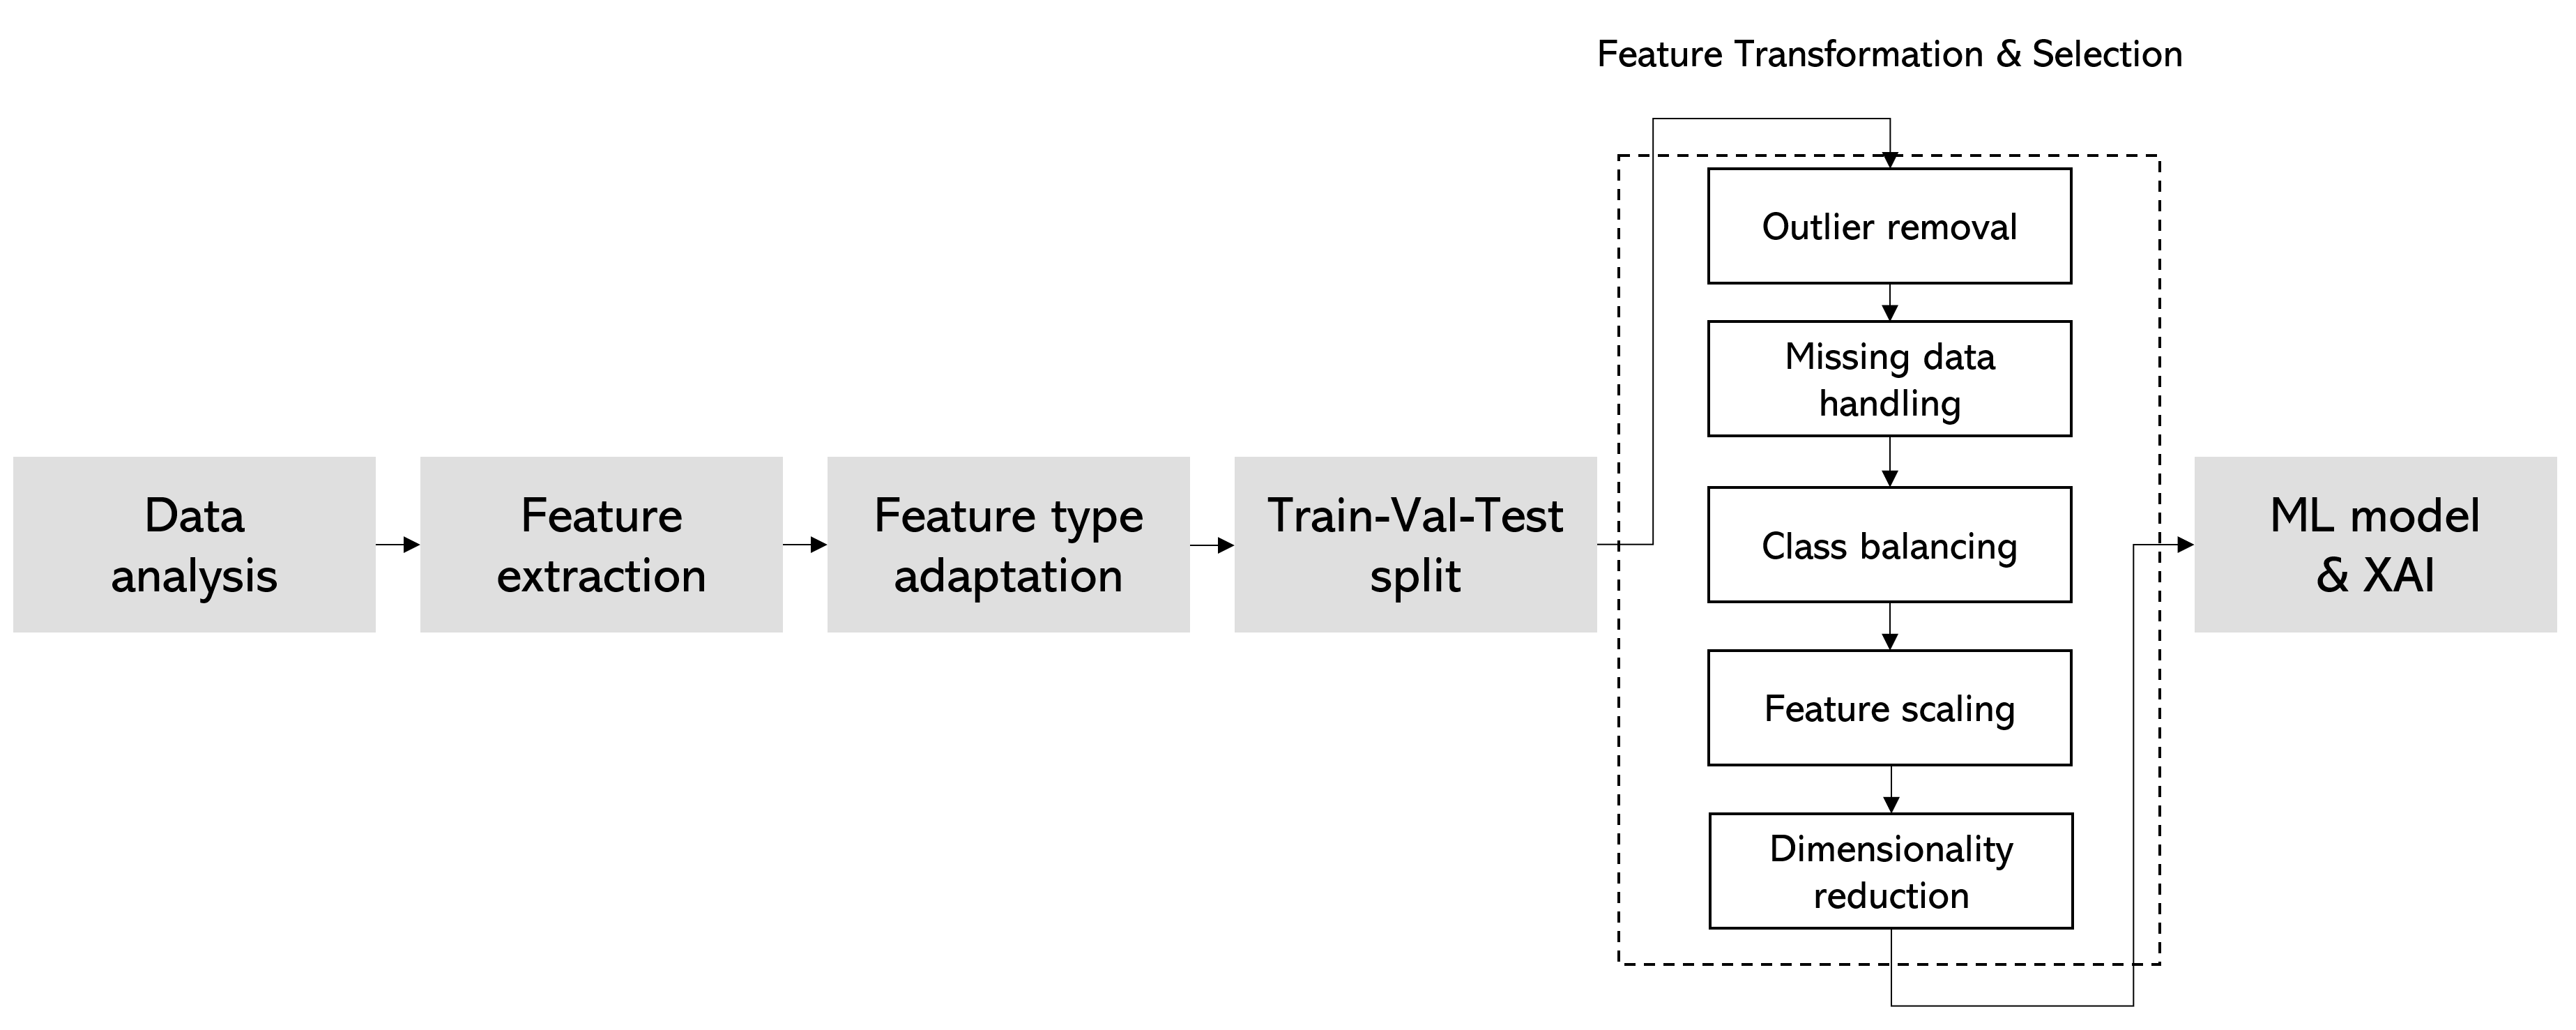

## **2.1.** Patient features


In [26]:
header

['A1501 12 500 5500 12-May-2020 12:33:59\n',
 'A1501.mat 16+24 1000/mV 16 0 248 -2054 0 I\n',
 'A1501.mat 16+24 1000/mV 16 0 722 476 0 II\n',
 'A1501.mat 16+24 1000/mV 16 0 474 2530 0 III\n',
 'A1501.mat 16+24 1000/mV 16 0 -485 -2154 0 aVR\n',
 'A1501.mat 16+24 1000/mV 16 0 -112 864 0 aVL\n',
 'A1501.mat 16+24 1000/mV 16 0 598 1832 0 aVF\n',
 'A1501.mat 16+24 1000/mV 16 0 -374 2684 0 V1\n',
 'A1501.mat 16+24 1000/mV 16 0 -482 -884 0 V2\n',
 'A1501.mat 16+24 1000/mV 16 0 262 -1917 0 V3\n',
 'A1501.mat 16+24 1000/mV 16 0 943 -841 0 V4\n',
 'A1501.mat 16+24 1000/mV 16 0 996 -288 0 V5\n',
 'A1501.mat 16+24 1000/mV 16 0 998 2639 0 V6\n',
 '#Age: 23\n',
 '#Sex: Female\n',
 '#Dx: 426783006\n',
 '#Rx: Unknown\n',
 '#Hx: Unknown\n',
 '#Sx: Unknown\n']

In [27]:
# Function to extract the relevant information provided in the header file.
def get_headerInfo(header_data):
  # analyze 1st row (e.g. 'A0824 12 500 9500 12-May-2020 12:33:59\n')
  tmp_hea = header_data[0].split(' ') # divide the row when a space is found
  ptID = tmp_hea[0] # first element
  num_leads = int(tmp_hea[1]) # second element
  sample_Fs= int(tmp_hea[2]) # third element

  # analyze the last group of rows
  for iline in header_data:
      if iline.startswith('#Age'):
          tmp_age = iline.split(': ')[1].strip()
          if tmp_age != 'NaN':
            age = int(tmp_age)
          else:
            age = np.nan

      elif iline.startswith('#Sex'):
          sex = iline.split(': ')[1]
          sex = sex.rstrip("\n")

      elif iline.startswith('#Dx'):
          label = iline.split(': ')[1]
          # Keep only the first diagnosis
          label = label.split(',')[0]
          label = label.rstrip("\n")

  return ptID, sample_Fs, age, sex, label


# load the data provided in the header file
patient_features = list()
for i in range(num_files):
    header = headers[i]
    patient_features_temp = get_headerInfo(header)
    patient_features.append(patient_features_temp)



In [28]:
patient_features_temp

('A1501', 500, 23, 'Female', '426783006')

In [29]:
# transform the lists into a pandas dataframe for better visualization and data handling
patient_features = pd.DataFrame(patient_features, columns =['ID' , 'fs' , 'age' , 'sex' , 'label'])

# visualize the dataframe
display(patient_features)

,ID,fs,age,sex,label
0,A0690,500,23.0,Female,426783006
1,A1329,500,66.0,Female,164889003
2,A2282,500,53.0,Male,164889003
3,A0179,500,29.0,Male,426783006
4,A0564,500,79.0,Female,164889003
...,...,...,...,...,...
755,A1432,500,85.0,Female,164889003
756,A1616,500,27.0,Female,426783006
757,A1630,500,28.0,Female,426783006
758,A0390,500,78.0,Female,164889003


## **2.2.** Signal rythm features


In [ ]:
header

In [30]:
def bandpass_filter(data, lowcut, highcut, signal_freq, filter_order):
        """
        Method responsible for creating and applying Butterworth filter.
        :param deque data: raw data
        :param float lowcut: filter lowcut frequency value
        :param float highcut: filter highcut frequency value
        :param int signal_freq: signal frequency in samples per second (Hz)
        :param int filter_order: filter order
        :return array: filtered data
        """
        nyquist_freq = 0.5 * signal_freq
        low = lowcut / nyquist_freq
        high = highcut / nyquist_freq
        b, a = butter(filter_order, [low, high], btype="band")
        y = lfilter(b, a, data)
        return y


def findpeaks(data, spacing=1, limit=None):
        """
        Janko Slavic peak detection algorithm and implementation.
        https://github.com/jankoslavic/py-tools/tree/master/findpeaks
        Finds peaks in `data` which are of `spacing` width and >=`limit`.
        :param ndarray data: data
        :param float spacing: minimum spacing to the next peak (should be 1 or more)
        :param float limit: peaks should have value greater or equal
        :return array: detected peaks indexes array
        """
        len = data.size
        x = np.zeros(len + 2 * spacing)
        x[:spacing] = data[0] - 1.e-6
        x[-spacing:] = data[-1] - 1.e-6
        x[spacing:spacing + len] = data
        peak_candidate = np.zeros(len)
        peak_candidate[:] = True
        for s in range(spacing):
            start = spacing - s - 1
            h_b = x[start: start + len]  # before
            start = spacing
            h_c = x[start: start + len]  # central
            start = spacing + s + 1
            h_a = x[start: start + len]  # after
            peak_candidate = np.logical_and(peak_candidate, np.logical_and(h_c > h_b, h_c > h_a))

        ind = np.argwhere(peak_candidate)
        ind = ind.reshape(ind.size)
        if limit is not None:
            ind = ind[data[ind] > limit]
        return ind


def detect_peaks(ecg_measurements,signal_frequency,gain):

        """
        Method responsible for extracting peaks from loaded ECG measurements data through measurements processing.
        This implementation of a QRS Complex Detector is by no means a certified medical tool and should not be used in health monitoring.
        It was created and used for experimental purposes in psychophysiology and psychology.
        You can find more information in module documentation:
        https://github.com/c-labpl/qrs_detector
        If you use these modules in a research project, please consider citing it:
        https://zenodo.org/record/583770
        If you use these modules in any other project, please refer to MIT open-source license.
        If you have any question on the implementation, please refer to:
        Michal Sznajder (Jagiellonian University) - technical contact (msznajder@gmail.com)
        Marta lukowska (Jagiellonian University)
        Janko Slavic peak detection algorithm and implementation.
        https://github.com/c-labpl/qrs_detector
        https://github.com/jankoslavic/py-tools/tree/master/findpeaks

        MIT License
        Copyright (c) 2017 Michal Sznajder, Marta Lukowska

        Permission is hereby granted, free of charge, to any person obtaining a copy
        of this software and associated documentation files (the "Software"), to deal
        in the Software without restriction, including without limitation the rights
        to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
        copies of the Software, and to permit persons to whom the Software is
        furnished to do so, subject to the following conditions:
        The above copyright notice and this permission notice shall be included in all
        copies or substantial portions of the Software.
        THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
        IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
        FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
        AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
        LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
        OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
        SOFTWARE.
        """

        filter_lowcut = 0.001
        filter_highcut = 15.0
        filter_order = 1
        integration_window = 30  # Change proportionally when adjusting frequency (in samples).
        findpeaks_limit = 0.35
        findpeaks_spacing = 100  # Change proportionally when adjusting frequency (in samples).
        refractory_period = 240  # Change proportionally when adjusting frequency (in samples).
        qrs_peak_filtering_factor = 0.125
        noise_peak_filtering_factor = 0.125
        qrs_noise_diff_weight = 0.25

        # Detection results.
        qrs_peaks_indices = np.array([], dtype=int)
        noise_peaks_indices = np.array([], dtype=int)

        # Measurements filtering - 0-15 Hz band pass filter.
        filtered_ecg_measurements = bandpass_filter(ecg_measurements, lowcut=filter_lowcut, highcut=filter_highcut, signal_freq=signal_frequency, filter_order=filter_order)
        filtered_ecg_measurements[:5] = filtered_ecg_measurements[5] # first 5 values are set constant to avoid common initial artifacts

        # Derivative - provides QRS slope information.
        differentiated_ecg_measurements = np.ediff1d(filtered_ecg_measurements)

        # Squaring - intensifies values received in derivative.
        squared_ecg_measurements = differentiated_ecg_measurements ** 2

        # Moving-window integration.
        integrated_ecg_measurements = np.convolve(squared_ecg_measurements, np.ones(integration_window)/integration_window)

        # Fiducial mark - peak detection on integrated measurements.
        detected_peaks_indices = findpeaks(data=integrated_ecg_measurements,
                                                     limit=findpeaks_limit,
                                                     spacing=findpeaks_spacing)

        detected_peaks_values = integrated_ecg_measurements[detected_peaks_indices]

        return detected_peaks_values,detected_peaks_indices


# Function for the computation of rhythm data
def get_rhythmfeatures(data, header_data):
  tmp_hea = header_data[0].split(' ')
  num_leads = int(tmp_hea[1])
  sample_Fs= int(tmp_hea[2])

  gain_lead = np.zeros(num_leads) # initialize the gain array
  for ii in range(num_leads):
     tmp_hea = header_data[ii+1].split(' ') # start from index 1 which is the second row, i.e., the first lead
     tmp_gain = tmp_hea[2].split('/')[0] # e.g. gain = 1000/mV means 1 mV = 1000 digital units
     gain_lead[ii] = int(tmp_gain) # take only the integer i.e., 1000

  #   detect peaks from LEAD I
  peaks,idx = detect_peaks(data[0],sample_Fs,gain_lead[0]) # peaks = amplitudes of peaks
  peak_amplitudes = peaks*gain_lead[0] # convert from mV to digital units

  # compute differences between consecutive peaks'
  # --> # samples composing RR intervals e.g., idx = [1000, 1500, 1900]
  idx = np.diff(idx)
  rr_intervals = idx/sample_Fs # convert from samples to duration in seconds
  rr_intervals = rr_intervals*1000 # to duration in ms

  #   mean
  mean_RR = np.mean(rr_intervals)
  mean_Peaks = np.mean(peak_amplitudes)

  #   median
  median_RR = np.median(rr_intervals)
  median_Peaks = np.median(peak_amplitudes)

  #   standard deviation
  std_RR = np.std(rr_intervals)
  std_Peaks = np.std(peak_amplitudes)

  #   variance
  var_RR = stats.tvar(rr_intervals)
  var_Peaks = stats.tvar(peak_amplitudes)

  #   Skewness
  skew_RR = stats.skew(rr_intervals)
  skew_Peaks = stats.skew(peak_amplitudes)

  #   Kurtosis
  kurt_RR = stats.kurtosis(rr_intervals)
  kurt_Peaks = stats.kurtosis(peak_amplitudes)

  features = np.hstack([mean_RR,mean_Peaks,median_RR,median_Peaks,std_RR,std_Peaks,
                        var_RR,var_Peaks,skew_RR,skew_Peaks,kurt_RR,kurt_Peaks])

  return features



In [31]:
# extraction of rythm features from ECG signals
rhythm_features = list()

for i in range(num_files):
  recording = recordings[i]
  header = headers[i]
  tmp = get_rhythmfeatures(recording, header)
  rhythm_features.append(tmp)

rhythm_features = np.array(rhythm_features)

rhythm_features = pd.DataFrame(rhythm_features, columns =['mean_RR', 'mean_Peaks', 'median_RR', 'median_Peaks',
                                                          'std_RR', 'std_Peaks', 'var_RR','var_Peaks','skew_RR',
                                                          'skew_Peaks','kurt_RR', 'kurt_Peaks'])

rhythm_features

,mean_RR,mean_Peaks,median_RR,median_Peaks,std_RR,std_Peaks,var_RR,var_Peaks,skew_RR,skew_Peaks,kurt_RR,kurt_Peaks
0,379.441176,364803.515943,355.0,4.020717e+04,91.153294,343159.356972,8432.936787,1.194901e+11,0.157923,0.124862,-1.761524,-1.876370
1,405.833333,728939.599856,353.0,1.275622e+06,140.962071,697337.880087,20734.231884,5.065418e+11,1.587053,-0.069778,1.629154,-1.982041
2,395.200000,506845.685071,396.0,4.889014e+05,80.381092,140610.186802,6730.333333,2.056207e+10,1.064752,0.249902,1.879745,-0.081226
3,376.054054,255810.485561,438.0,1.996086e+05,117.453601,243889.181911,14178.552553,6.108955e+10,0.831046,0.076725,0.845093,-1.905434
4,310.451613,971479.300699,310.0,9.517872e+05,41.527945,151589.710764,1782.055914,2.372071e+10,0.301192,0.078959,-1.132885,-0.654985
...,...,...,...,...,...,...,...,...,...,...,...,...
755,472.173913,475977.577746,384.0,7.241665e+05,167.924324,396819.482717,29480.332016,1.643120e+11,1.006029,-0.209783,0.002713,-1.826354
756,391.155556,79234.464079,412.0,6.911702e+04,132.415165,24160.991312,17932.270707,5.967258e+08,0.072932,0.369431,-1.879713,-1.417926
757,313.021277,38702.010336,294.0,5.287974e+04,33.177466,19825.690526,1124.673451,4.014209e+08,0.230983,-0.022180,-1.687386,-1.892976
758,522.777778,314355.900716,464.0,3.174238e+05,115.835398,25819.302025,14207.124183,7.036717e+08,0.206485,-0.491784,-1.629400,-0.107052


## **3.3.** Signal morphological features



In [32]:
# Load the provided .csv file
morph_features = pd.read_csv (r'morphological_features.csv')
display(morph_features)


,QRSTang,QRSTang_M,AZ_OQ,AZ_OQM,AZ_OT,AZ_OTM,AZ_SVG,AZ_SVG_M,EL_OQ,EL_OQM,...,EL_SVG,EL_SVG_M,QRS_Mag,QRS_Mag_M,T_Mag,T_Mag_M,SVG_Mag,QT_interval,AUC_VM_QT,WVG
0,74.724892,96.631139,64.338772,63.672258,-26.835159,-41.981403,50.420224,18.699131,63.860422,77.617773,...,56.014235,57.389989,5.757267e+05,1.565570e+07,164200.172718,1.446059e+07,6.389319e+05,358.0,5.278774e+07,2.004804e+07
1,158.629882,170.528185,30.557931,15.625854,-129.141515,-174.876146,28.355415,26.651050,41.754297,48.664039,...,40.684923,45.177466,7.333811e+05,2.751523e+07,58626.498164,1.339862e+07,6.791215e+05,258.0,5.956400e+07,1.446827e+07
2,98.290360,82.823308,51.246764,15.194965,-55.825931,-69.322916,27.406239,-16.910619,65.364801,79.466301,...,59.241021,76.261626,7.429733e+05,3.727852e+07,285525.338022,2.497948e+07,7.565434e+05,302.0,1.075152e+08,4.739547e+07
3,136.974582,146.995765,51.606255,49.247858,179.060356,-168.978887,63.544029,84.675849,45.539513,48.311435,...,46.148965,49.675890,5.870813e+05,2.151710e+07,111738.676057,1.116458e+07,5.111130e+05,308.0,4.339884e+07,1.359066e+07
4,93.088120,96.987031,70.817771,65.559945,-22.343324,-34.367545,33.535784,-1.271836,90.135643,72.360329,...,80.860389,73.083694,4.715546e+05,2.329259e+07,357247.744320,3.772234e+07,5.760547e+05,404.0,7.028715e+07,4.185395e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
755,162.265902,167.557696,50.614311,62.456127,-110.806797,-104.676842,40.482077,22.987191,72.365646,75.294521,...,74.443093,79.760609,8.663423e+05,5.571063e+07,321738.042216,4.474773e+07,5.684053e+05,294.0,1.176203e+08,1.540408e+07
756,20.206481,20.456661,26.439068,14.060227,3.088871,-9.010904,20.831474,5.142154,60.226082,62.005713,...,58.827567,61.925544,7.370448e+05,3.584437e+07,246880.813594,2.252404e+07,9.724770e+05,320.0,6.893324e+07,5.748949e+07
757,98.584733,93.949365,45.268497,32.214738,-50.465722,-62.366956,26.992545,-20.393458,72.852501,92.200229,...,76.380576,102.067885,1.151615e+06,3.595969e+07,359958.785498,4.385930e+07,1.154136e+06,360.0,1.345750e+08,5.476754e+07
758,124.363558,148.031027,102.535144,73.865964,-57.262311,-76.449944,101.691162,66.577466,81.244260,84.279626,...,78.633262,81.476343,6.269833e+05,2.208274e+07,35199.140104,4.662936e+06,6.078104e+05,444.0,5.704062e+07,1.829436e+07


## 3.4. Combine all features

In [33]:
# concatenate all features in a single dataframe
features = pd.concat([patient_features, rhythm_features, morph_features], axis=1)
features = pd.DataFrame(features)
features = features.set_index('ID') # use ID as index not as feature
features = features.drop(columns=['fs']) # drop "useless" features
display(features)

,age,sex,label,mean_RR,mean_Peaks,median_RR,median_Peaks,std_RR,std_Peaks,var_RR,...,EL_SVG,EL_SVG_M,QRS_Mag,QRS_Mag_M,T_Mag,T_Mag_M,SVG_Mag,QT_interval,AUC_VM_QT,WVG
ID,,,,,,,,,,,,,,,,,,,,,
A0690,23.0,Female,426783006,379.441176,364803.515943,355.0,4.020717e+04,91.153294,343159.356972,8432.936787,...,56.014235,57.389989,5.757267e+05,1.565570e+07,164200.172718,1.446059e+07,6.389319e+05,358.0,5.278774e+07,2.004804e+07
A1329,66.0,Female,164889003,405.833333,728939.599856,353.0,1.275622e+06,140.962071,697337.880087,20734.231884,...,40.684923,45.177466,7.333811e+05,2.751523e+07,58626.498164,1.339862e+07,6.791215e+05,258.0,5.956400e+07,1.446827e+07
A2282,53.0,Male,164889003,395.200000,506845.685071,396.0,4.889014e+05,80.381092,140610.186802,6730.333333,...,59.241021,76.261626,7.429733e+05,3.727852e+07,285525.338022,2.497948e+07,7.565434e+05,302.0,1.075152e+08,4.739547e+07
A0179,29.0,Male,426783006,376.054054,255810.485561,438.0,1.996086e+05,117.453601,243889.181911,14178.552553,...,46.148965,49.675890,5.870813e+05,2.151710e+07,111738.676057,1.116458e+07,5.111130e+05,308.0,4.339884e+07,1.359066e+07
A0564,79.0,Female,164889003,310.451613,971479.300699,310.0,9.517872e+05,41.527945,151589.710764,1782.055914,...,80.860389,73.083694,4.715546e+05,2.329259e+07,357247.744320,3.772234e+07,5.760547e+05,404.0,7.028715e+07,4.185395e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A1432,85.0,Female,164889003,472.173913,475977.577746,384.0,7.241665e+05,167.924324,396819.482717,29480.332016,...,74.443093,79.760609,8.663423e+05,5.571063e+07,321738.042216,4.474773e+07,5.684053e+05,294.0,1.176203e+08,1.540408e+07
A1616,27.0,Female,426783006,391.155556,79234.464079,412.0,6.911702e+04,132.415165,24160.991312,17932.270707,...,58.827567,61.925544,7.370448e+05,3.584437e+07,246880.813594,2.252404e+07,9.724770e+05,320.0,6.893324e+07,5.748949e+07
A1630,28.0,Female,426783006,313.021277,38702.010336,294.0,5.287974e+04,33.177466,19825.690526,1124.673451,...,76.380576,102.067885,1.151615e+06,3.595969e+07,359958.785498,4.385930e+07,1.154136e+06,360.0,1.345750e+08,5.476754e+07


In [34]:
labels = features.label
print(np.shape(labels))

(760,)


# **3.** Feature type adaptation

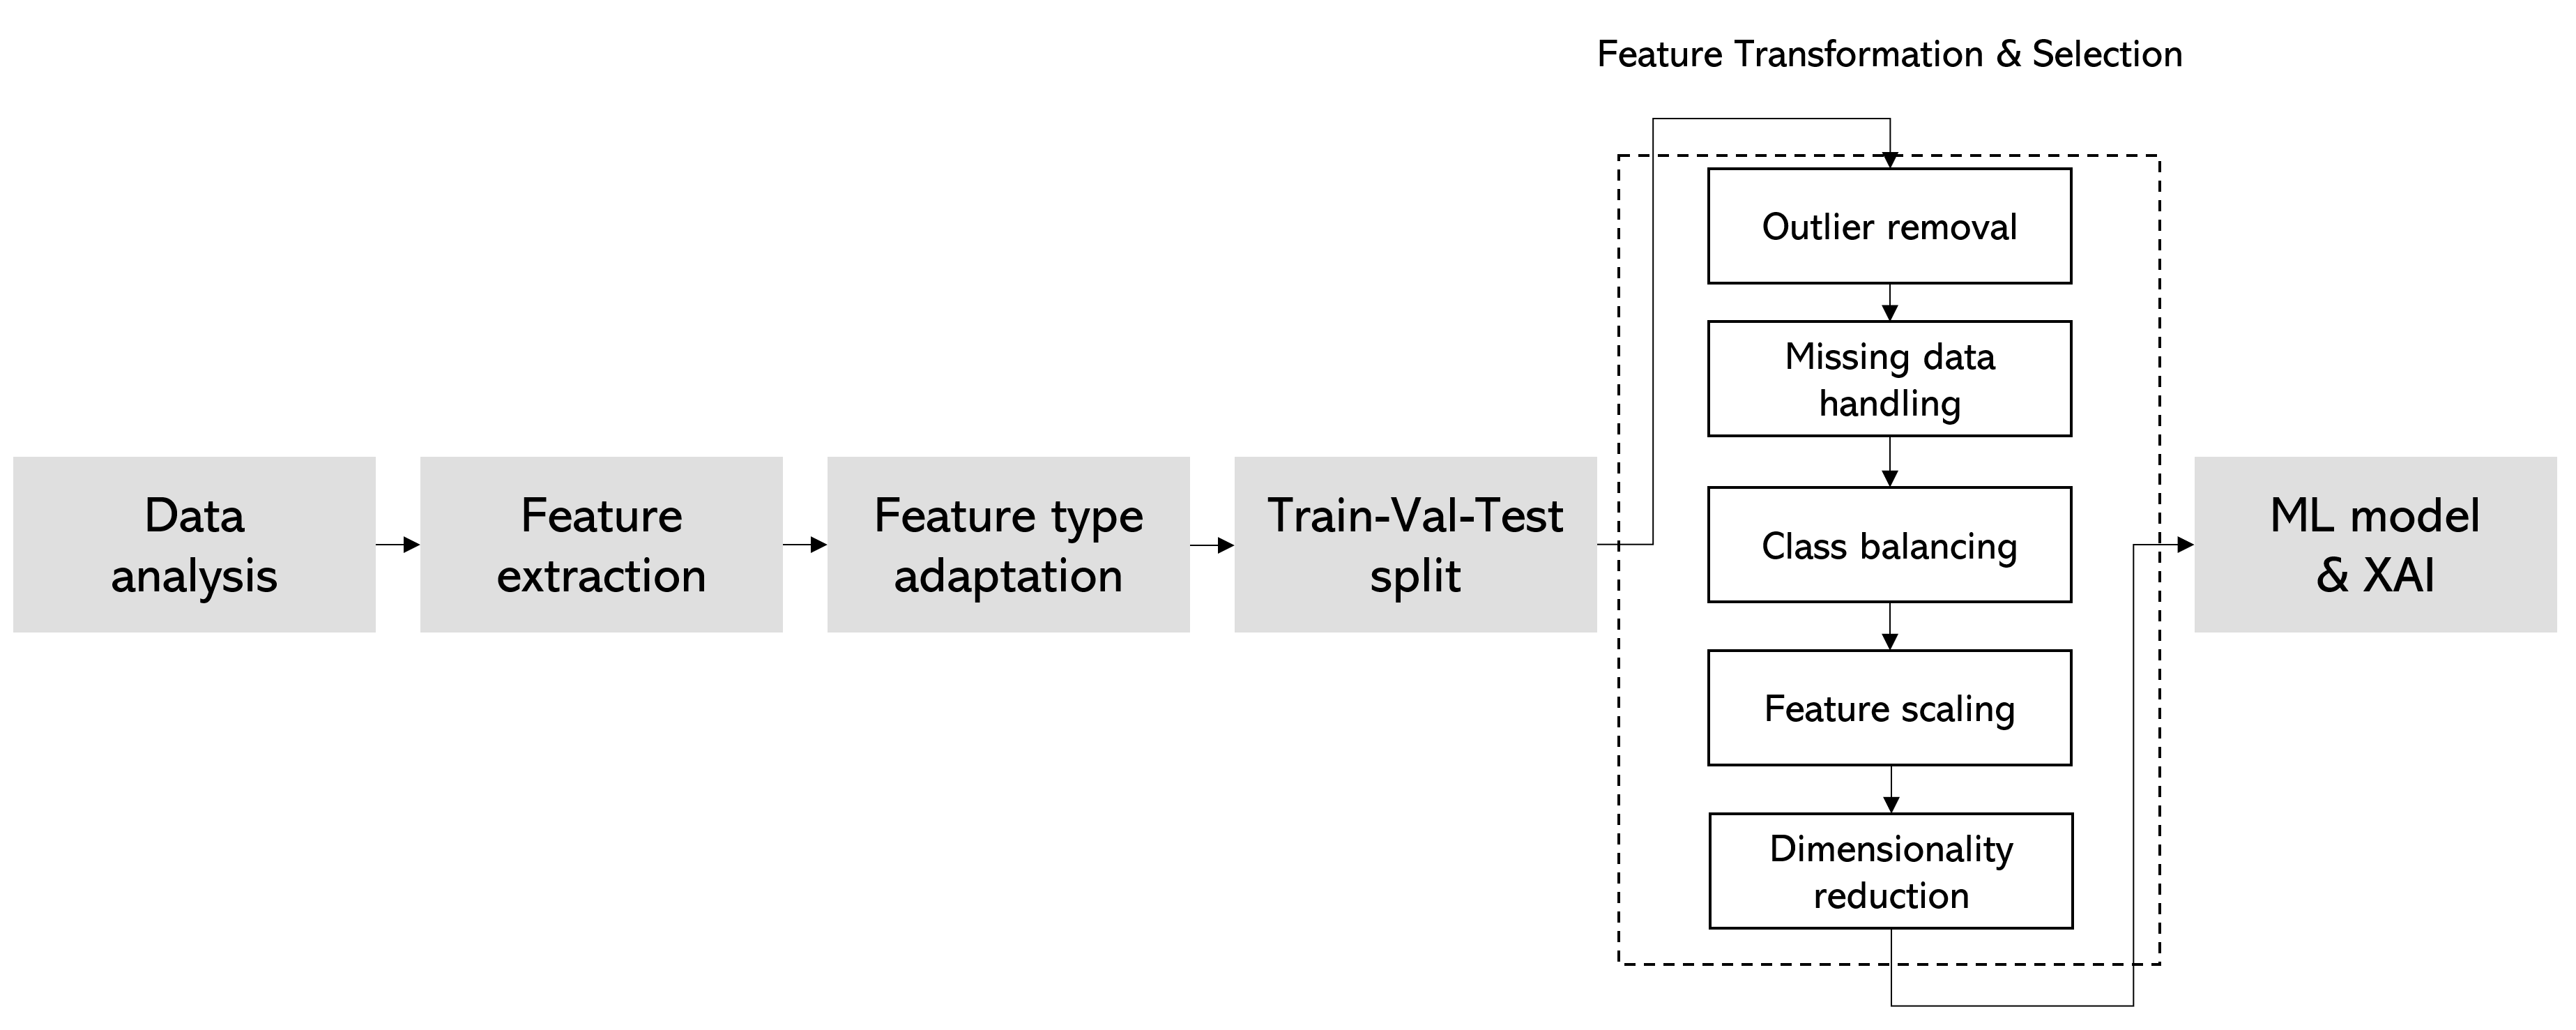

In [35]:
summary = pd.DataFrame({
    "column": features.columns,
    "dtype": features.dtypes.values,
    "unique_values": [features[col].nunique() for col in features.columns]
})

display(summary)


,column,dtype,unique_values
0,age,float64,85
1,sex,str,2
2,label,str,2
3,mean_RR,float64,723
4,mean_Peaks,float64,742
5,median_RR,float64,287
6,median_Peaks,float64,742
7,std_RR,float64,742
8,std_Peaks,float64,742
9,var_RR,float64,742


In [36]:
# In this case we have to adapt the string categorical variable female/male to a numerical variable
sex = features.sex
sex_binary = list()
for sex_temp in sex:
  if sex_temp == 'Female':
      sex_binary.append(1)
  else:
      sex_binary.append(0)

features.sex = sex_binary
display(features)


,age,sex,label,mean_RR,mean_Peaks,median_RR,median_Peaks,std_RR,std_Peaks,var_RR,...,EL_SVG,EL_SVG_M,QRS_Mag,QRS_Mag_M,T_Mag,T_Mag_M,SVG_Mag,QT_interval,AUC_VM_QT,WVG
ID,,,,,,,,,,,,,,,,,,,,,
A0690,23.0,1,426783006,379.441176,364803.515943,355.0,4.020717e+04,91.153294,343159.356972,8432.936787,...,56.014235,57.389989,5.757267e+05,1.565570e+07,164200.172718,1.446059e+07,6.389319e+05,358.0,5.278774e+07,2.004804e+07
A1329,66.0,1,164889003,405.833333,728939.599856,353.0,1.275622e+06,140.962071,697337.880087,20734.231884,...,40.684923,45.177466,7.333811e+05,2.751523e+07,58626.498164,1.339862e+07,6.791215e+05,258.0,5.956400e+07,1.446827e+07
A2282,53.0,0,164889003,395.200000,506845.685071,396.0,4.889014e+05,80.381092,140610.186802,6730.333333,...,59.241021,76.261626,7.429733e+05,3.727852e+07,285525.338022,2.497948e+07,7.565434e+05,302.0,1.075152e+08,4.739547e+07
A0179,29.0,0,426783006,376.054054,255810.485561,438.0,1.996086e+05,117.453601,243889.181911,14178.552553,...,46.148965,49.675890,5.870813e+05,2.151710e+07,111738.676057,1.116458e+07,5.111130e+05,308.0,4.339884e+07,1.359066e+07
A0564,79.0,1,164889003,310.451613,971479.300699,310.0,9.517872e+05,41.527945,151589.710764,1782.055914,...,80.860389,73.083694,4.715546e+05,2.329259e+07,357247.744320,3.772234e+07,5.760547e+05,404.0,7.028715e+07,4.185395e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A1432,85.0,1,164889003,472.173913,475977.577746,384.0,7.241665e+05,167.924324,396819.482717,29480.332016,...,74.443093,79.760609,8.663423e+05,5.571063e+07,321738.042216,4.474773e+07,5.684053e+05,294.0,1.176203e+08,1.540408e+07
A1616,27.0,1,426783006,391.155556,79234.464079,412.0,6.911702e+04,132.415165,24160.991312,17932.270707,...,58.827567,61.925544,7.370448e+05,3.584437e+07,246880.813594,2.252404e+07,9.724770e+05,320.0,6.893324e+07,5.748949e+07
A1630,28.0,1,426783006,313.021277,38702.010336,294.0,5.287974e+04,33.177466,19825.690526,1124.673451,...,76.380576,102.067885,1.151615e+06,3.595969e+07,359958.785498,4.385930e+07,1.154136e+06,360.0,1.345750e+08,5.476754e+07


In [37]:
label_binary = list()
for label_temp in labels:
  if label_temp == '426783006': # normal synus rythm
      label_binary.append(0)
  else: # atrial fibrillation
      label_binary.append(1)

features.label = label_binary
display(features)

,age,sex,label,mean_RR,mean_Peaks,median_RR,median_Peaks,std_RR,std_Peaks,var_RR,...,EL_SVG,EL_SVG_M,QRS_Mag,QRS_Mag_M,T_Mag,T_Mag_M,SVG_Mag,QT_interval,AUC_VM_QT,WVG
ID,,,,,,,,,,,,,,,,,,,,,
A0690,23.0,1,0,379.441176,364803.515943,355.0,4.020717e+04,91.153294,343159.356972,8432.936787,...,56.014235,57.389989,5.757267e+05,1.565570e+07,164200.172718,1.446059e+07,6.389319e+05,358.0,5.278774e+07,2.004804e+07
A1329,66.0,1,1,405.833333,728939.599856,353.0,1.275622e+06,140.962071,697337.880087,20734.231884,...,40.684923,45.177466,7.333811e+05,2.751523e+07,58626.498164,1.339862e+07,6.791215e+05,258.0,5.956400e+07,1.446827e+07
A2282,53.0,0,1,395.200000,506845.685071,396.0,4.889014e+05,80.381092,140610.186802,6730.333333,...,59.241021,76.261626,7.429733e+05,3.727852e+07,285525.338022,2.497948e+07,7.565434e+05,302.0,1.075152e+08,4.739547e+07
A0179,29.0,0,0,376.054054,255810.485561,438.0,1.996086e+05,117.453601,243889.181911,14178.552553,...,46.148965,49.675890,5.870813e+05,2.151710e+07,111738.676057,1.116458e+07,5.111130e+05,308.0,4.339884e+07,1.359066e+07
A0564,79.0,1,1,310.451613,971479.300699,310.0,9.517872e+05,41.527945,151589.710764,1782.055914,...,80.860389,73.083694,4.715546e+05,2.329259e+07,357247.744320,3.772234e+07,5.760547e+05,404.0,7.028715e+07,4.185395e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A1432,85.0,1,1,472.173913,475977.577746,384.0,7.241665e+05,167.924324,396819.482717,29480.332016,...,74.443093,79.760609,8.663423e+05,5.571063e+07,321738.042216,4.474773e+07,5.684053e+05,294.0,1.176203e+08,1.540408e+07
A1616,27.0,1,0,391.155556,79234.464079,412.0,6.911702e+04,132.415165,24160.991312,17932.270707,...,58.827567,61.925544,7.370448e+05,3.584437e+07,246880.813594,2.252404e+07,9.724770e+05,320.0,6.893324e+07,5.748949e+07
A1630,28.0,1,0,313.021277,38702.010336,294.0,5.287974e+04,33.177466,19825.690526,1124.673451,...,76.380576,102.067885,1.151615e+06,3.595969e+07,359958.785498,4.385930e+07,1.154136e+06,360.0,1.345750e+08,5.476754e+07


In [38]:
# save in the session folder
path = ""
features.to_csv(path + 'features_full.csv')

# **4.** Train-Val-Test split
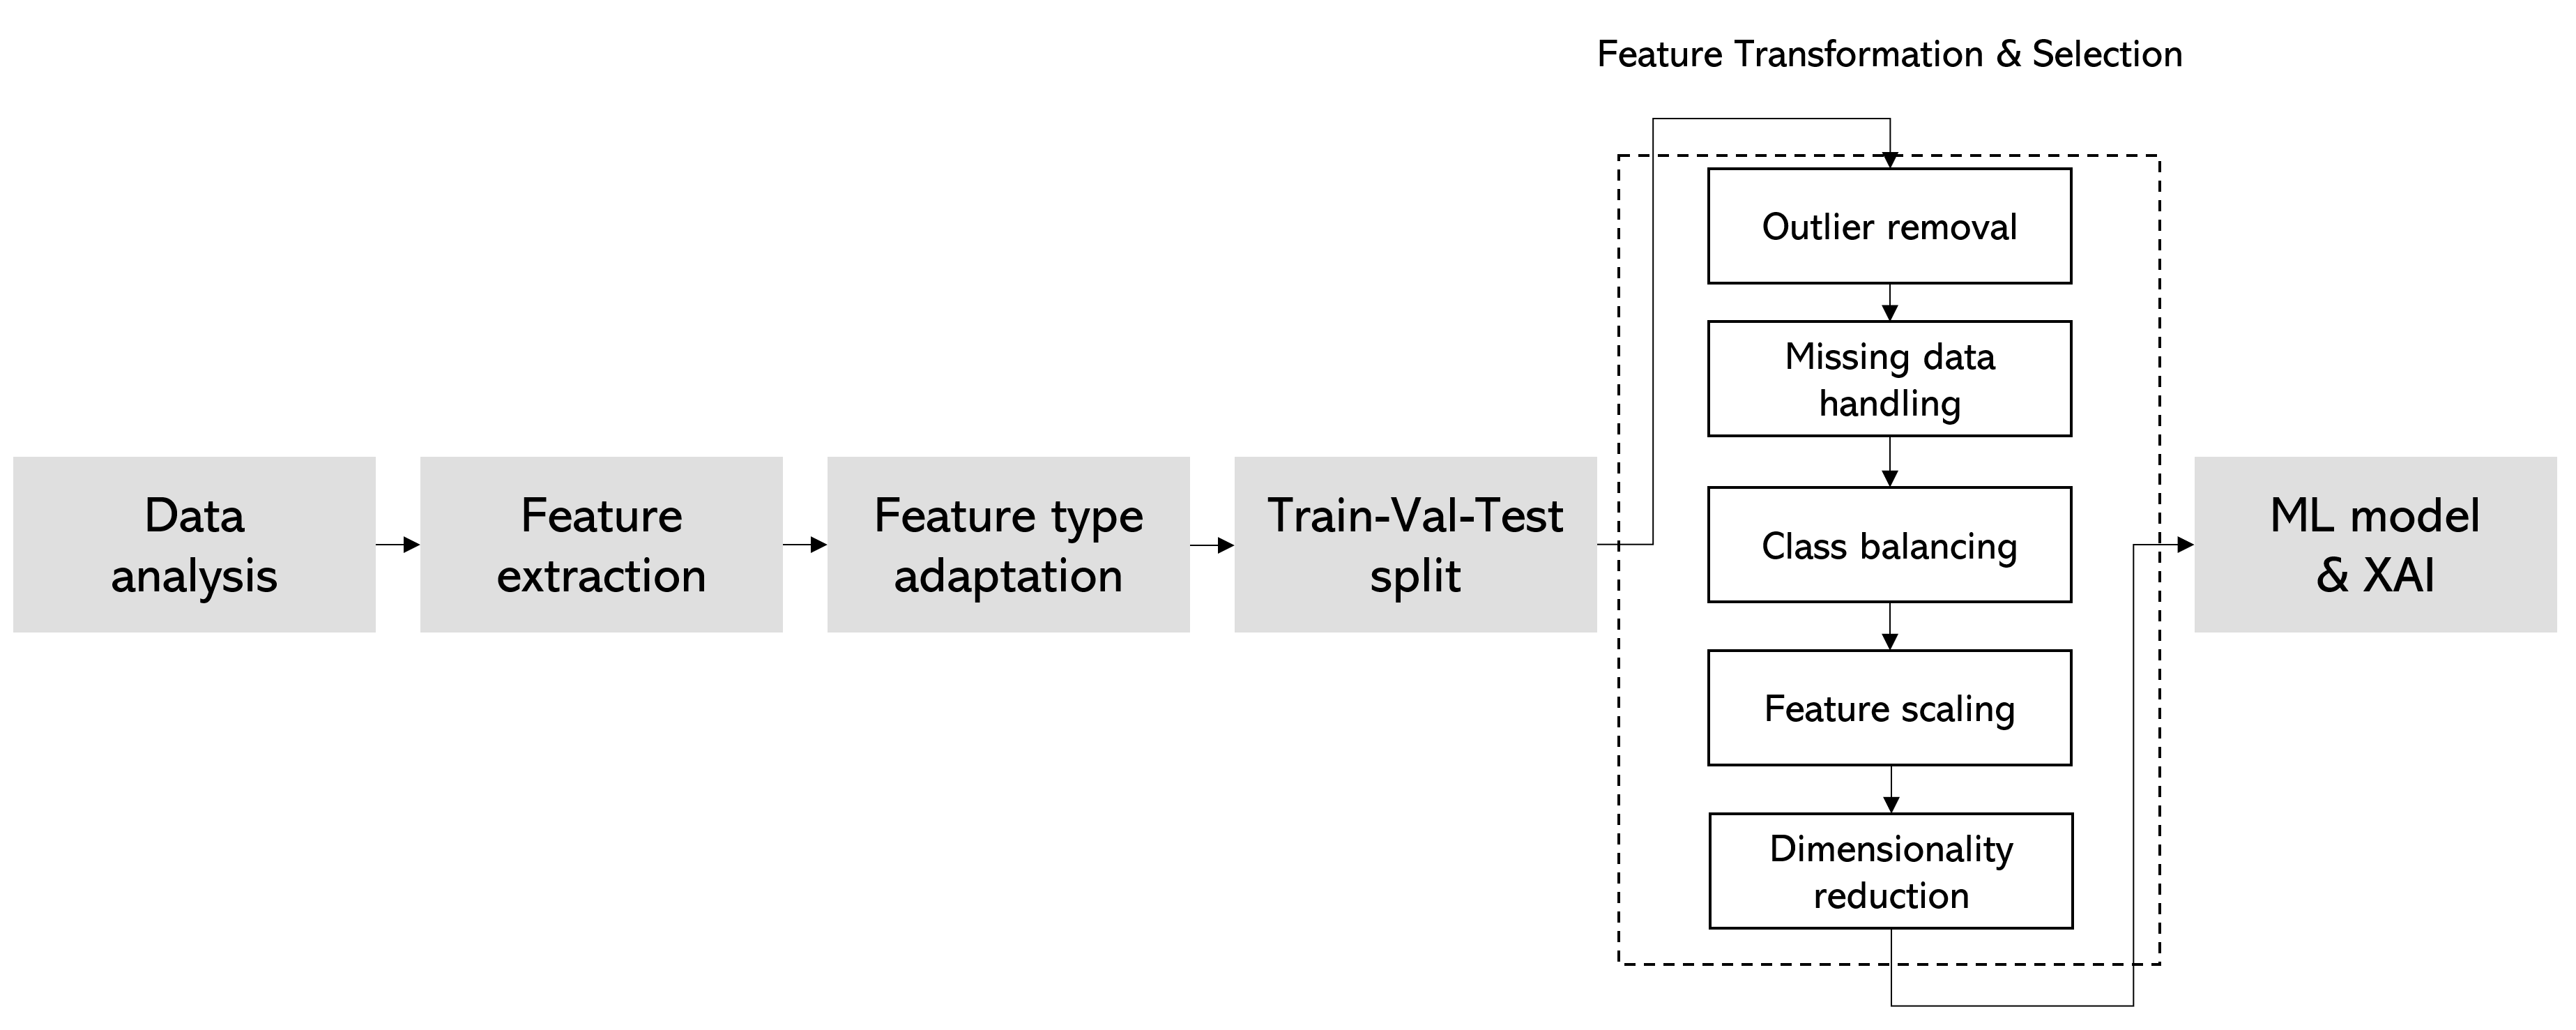

Total training patients: 486
Total validation patients: 122
Total test patients: 152


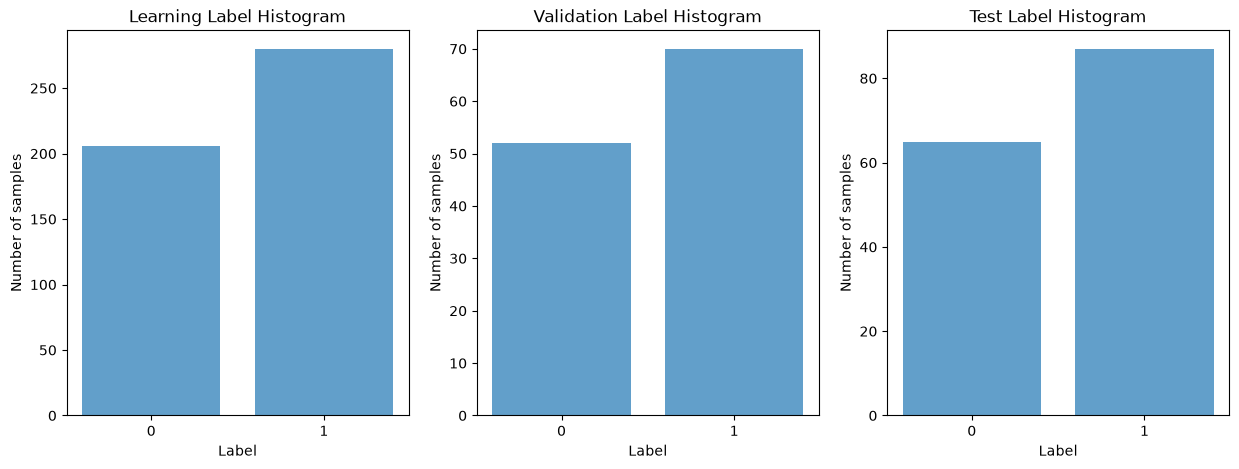

In [40]:
# split the entire dataset into training and test
labels = features.label
training, test = train_test_split(features, test_size=0.2, shuffle=True, random_state=SEED,
                                    stratify=labels)
training_labels = training.label

# further split training set into training and val
learning, validation = train_test_split(training, test_size=0.2,
                                     shuffle=True, stratify=training_labels)

learning_labels = learning.label
learning_features = learning.drop(columns='label')

validation_labels = validation.label
validation_features = validation.drop(columns='label')

test_labels = test.label
test_features = test.drop(columns='label')

# plot label histograms

# calculate the label counts for train, validation, and test sets
learning_label_counts = learning_labels.value_counts().sort_index()
validation_label_counts = validation_labels.value_counts().sort_index()
test_label_counts = test_labels.value_counts().sort_index()

# create subplots for the histograms
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# plot histograms for each dataset
ax1.bar(learning_label_counts.index, learning_label_counts.values, align='center', alpha=0.7)
ax1.set_xticks(learning_label_counts.index)
ax1.set_xlabel("Label")
ax1.set_ylabel("Number of samples")
ax1.set_title("Learning Label Histogram")
print('Total training patients: ' + str(np.shape(learning)[0]))


ax2.bar(validation_label_counts.index, validation_label_counts.values, align='center', alpha=0.7)
ax2.set_xticks(validation_label_counts.index)
ax2.set_xlabel("Label")
ax2.set_ylabel("Number of samples")
ax2.set_title("Validation Label Histogram")
print('Total validation patients: ' + str(np.shape(validation)[0]))


ax3.bar(test_label_counts.index, test_label_counts.values, align='center', alpha=0.7)
ax3.set_xticks(test_label_counts.index)
ax3.set_xlabel("Label")
ax3.set_ylabel("Number of samples")
ax3.set_title("Test Label Histogram")
print('Total test patients: ' + str(np.shape(test)[0]))
